# Module 2 — Batch Forecasting (SKU × Branch)
**MADT6004 Wrap-Up · Brew Lab BKK case**

Khun Ploy: *"Stop telling me about the past. How much will each SKU sell at each branch over the next 30 days?"*

What you'll do:
1. Build a daily-level **SKU × Branch** demand panel.
2. Loop a **batch forecast** across many series (top 5 SKUs × 12 branches = 60 series).
3. Compare three methods: **Naive**, **Seasonal Naive (weekly)**, **Holt-Winters**.
4. Evaluate with **RMSE** on a holdout window.
5. Pick the winning method per series and produce 30-day forecasts.

## 1. Setup

In [ ]:
# Bootstrap — pulls the dataset into the runtime when the notebook is opened in Colab.
# Local Jupyter runs from .../notebooks/ and finds ../data/brewlab.db directly, so this is a no-op.
import os
if not os.path.exists("../data/brewlab.db"):
    if not os.path.exists("MADT6004"):
        os.system("git clone -q https://github.com/thanachart/MADT6004.git")
    os.chdir("MADT6004/Integrated Data Analytics Exercise/notebooks")

In [1]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

conn = sqlite3.connect("../data/brewlab.db")
print("Loaded.")

Loaded.


## 2. Build daily SKU × Branch panel

In [2]:
daily = pd.read_sql('''
SELECT date(t.datetime)  AS d,
       t.branch_id,
       oi.product_id,
       SUM(oi.qty)        AS units
FROM transactions t
JOIN order_items oi ON t.order_id = oi.order_id
GROUP BY date(t.datetime), t.branch_id, oi.product_id
''', conn)
daily['d'] = pd.to_datetime(daily['d'])

products = pd.read_sql("SELECT product_id, name AS product, category FROM products", conn)
branches = pd.read_sql("SELECT branch_id, name AS branch FROM branches", conn)
daily = daily.merge(products, on='product_id').merge(branches, on='branch_id')

# Pick top 5 SKUs by total units
top_skus = (daily.groupby(['product_id','product'])['units'].sum()
            .sort_values(ascending=False).head(5).reset_index())
print("Top 5 SKUs:")
print(top_skus)

target_skus = top_skus['product_id'].tolist()
target_branches = branches['branch_id'].tolist()
print(f"\nTotal series to forecast: {len(target_skus)} SKUs × {len(target_branches)} branches = {len(target_skus)*len(target_branches)}")

Top 5 SKUs:
   product_id            product  units
0           7          Cold Brew  19874
1           4         Cappuccino  19823
2          11  Caramel Macchiato  19698
3           1           Espresso  19679
4           6         Flat White  19657

Total series to forecast: 5 SKUs × 12 branches = 60


## 3. Define forecasting functions

Three baseline methods:
- **Naive** — predict the last value forever
- **Seasonal Naive** — predict the same day-of-week from last week
- **Holt-Winters** — exponential smoothing with trend + weekly seasonality

In [3]:
def make_series(daily, sku, branch):
    """Return a daily series, zero-filled for missing days."""
    sub = daily[(daily.product_id == sku) & (daily.branch_id == branch)][['d', 'units']]
    if len(sub) == 0:
        return None
    sub = sub.set_index('d').sort_index()
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='D')
    sub = sub.reindex(full_idx, fill_value=0)
    sub.index.name = 'd'
    return sub['units']

def forecast_naive(train, h):
    return np.repeat(train.iloc[-1], h)

def forecast_seasonal_naive(train, h, season=7):
    last_season = train.iloc[-season:].values
    return np.tile(last_season, int(np.ceil(h / season)))[:h]

def forecast_holt_winters(train, h):
    if len(train) < 21:
        return forecast_seasonal_naive(train, h)
    try:
        m = ExponentialSmoothing(train, seasonal_periods=7,
                                  trend="add", seasonal="add",
                                  initialization_method="estimated").fit()
        return m.forecast(h).values
    except Exception:
        return forecast_seasonal_naive(train, h)

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2)))

## 4. Batch loop — forecast all series + collect RMSE

In [4]:
HOLDOUT_DAYS = 14

records = []
for sku in target_skus:
    for br in target_branches:
        s = make_series(daily, sku, br)
        if s is None or len(s) < 60:
            continue
        train = s.iloc[:-HOLDOUT_DAYS]
        test  = s.iloc[-HOLDOUT_DAYS:]

        preds = {
            "naive":          forecast_naive(train, HOLDOUT_DAYS),
            "seasonal_naive": forecast_seasonal_naive(train, HOLDOUT_DAYS),
            "holt_winters":   forecast_holt_winters(train, HOLDOUT_DAYS),
        }
        for method, p in preds.items():
            records.append({
                "sku_id": sku, "branch_id": br, "method": method,
                "rmse": rmse(test.values, p),
                "test_mean": float(test.mean()),
                "n_train": len(train),
            })

eval_df = pd.DataFrame(records)
eval_df = eval_df.merge(products[['product_id','product']], left_on='sku_id', right_on='product_id', how='left') \
                 .merge(branches, on='branch_id', how='left')
print(f"Evaluated {eval_df.groupby(['sku_id','branch_id']).ngroups} series × 3 methods.")
eval_df.head()

Evaluated 60 series × 3 methods.


,sku_id,branch_id,method,rmse,test_mean,n_train,product_id,product,branch
0,7,1,naive,2.853569,8.857143,339,7,Cold Brew,Asoke
1,7,1,seasonal_naive,4.053217,8.857143,339,7,Cold Brew,Asoke
2,7,1,holt_winters,2.577265,8.857143,339,7,Cold Brew,Asoke
3,7,2,naive,1.832251,5.642857,343,7,Cold Brew,Sukhumvit 24
4,7,2,seasonal_naive,4.097037,5.642857,343,7,Cold Brew,Sukhumvit 24


## 5. Method comparison — which baseline wins overall?

In [5]:
summary = eval_df.groupby('method').agg(
    mean_rmse=('rmse','mean'),
    median_rmse=('rmse','median'),
    n=('rmse','count')
).sort_values('mean_rmse')
print(summary)

# Pick winner per series
wins = (eval_df.sort_values('rmse')
              .groupby(['sku_id','branch_id']).head(1)
              .groupby('method').size().reset_index(name='wins'))
print("\nWins per method (lowest RMSE on each series):")
print(wins.sort_values('wins', ascending=False))

                mean_rmse  median_rmse   n
method                                    
holt_winters     2.895710     2.827192  60
naive            3.593312     3.294572  60
seasonal_naive   4.003835     3.977492  60

Wins per method (lowest RMSE on each series):
         method  wins
0  holt_winters    41
1         naive    19


## 6. Visualize — RMSE distribution by method

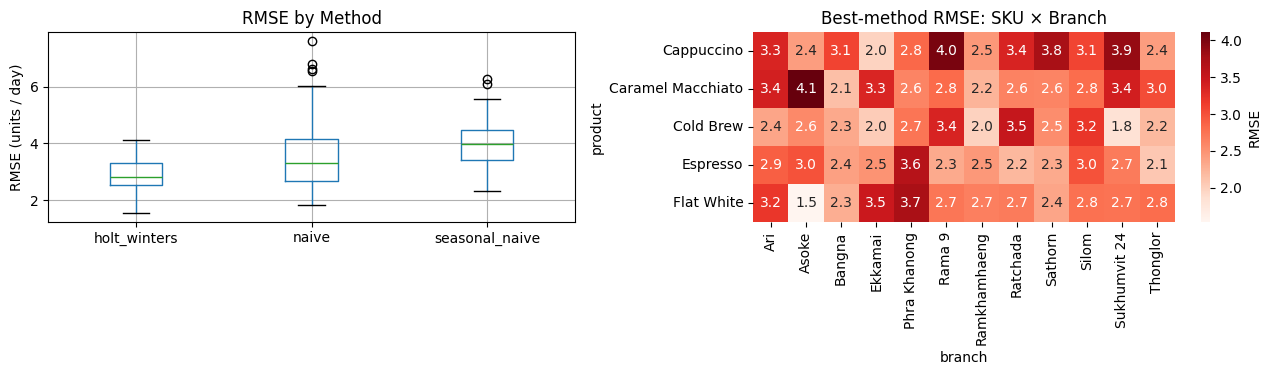

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eval_df.boxplot(column='rmse', by='method', ax=axes[0])
axes[0].set_title("RMSE by Method")
axes[0].set_ylabel("RMSE (units / day)")
axes[0].set_xlabel("")
plt.suptitle("")

# Heatmap: best method's RMSE by SKU × Branch
best = eval_df.sort_values('rmse').groupby(['sku_id','branch_id']).head(1)
pv = best.pivot(index='product', columns='branch', values='rmse')
import seaborn as sns
sns.heatmap(pv, annot=True, fmt=".1f", cmap="Reds", ax=axes[1], cbar_kws={'label':'RMSE'})
axes[1].set_title("Best-method RMSE: SKU × Branch")
plt.tight_layout()
plt.show()

## 7. Generate the 30-day forecast for each series

In [7]:
FORECAST_HORIZON = 30
final = []
for sku in target_skus:
    for br in target_branches:
        s = make_series(daily, sku, br)
        if s is None or len(s) < 60:
            continue
        # Pick winning method on holdout
        sub = eval_df[(eval_df.sku_id == sku) & (eval_df.branch_id == br)].sort_values('rmse')
        if sub.empty:
            continue
        best_method = sub.iloc[0]['method']
        if best_method == "naive":
            fc = forecast_naive(s, FORECAST_HORIZON)
        elif best_method == "seasonal_naive":
            fc = forecast_seasonal_naive(s, FORECAST_HORIZON)
        else:
            fc = forecast_holt_winters(s, FORECAST_HORIZON)
        future_dates = pd.date_range(s.index.max() + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='D')
        for d, v in zip(future_dates, fc):
            final.append({"sku_id": sku, "branch_id": br, "date": d, "forecast": max(0, float(v)),
                          "method": best_method})

forecast_df = pd.DataFrame(final)
forecast_df = forecast_df.merge(products[['product_id','product']], left_on='sku_id', right_on='product_id') \
                          .merge(branches, on='branch_id')
print(f"30-day forecasts: {len(forecast_df)} rows ({forecast_df.groupby(['sku_id','branch_id']).ngroups} series)")
forecast_df.head()

30-day forecasts: 1800 rows (60 series)


,sku_id,branch_id,date,forecast,method,product_id,product,branch
0,7,1,2026-05-01,8.254462,holt_winters,7,Cold Brew,Asoke
1,7,1,2026-05-02,9.393698,holt_winters,7,Cold Brew,Asoke
2,7,1,2026-05-03,8.773764,holt_winters,7,Cold Brew,Asoke
3,7,1,2026-05-04,9.414466,holt_winters,7,Cold Brew,Asoke
4,7,1,2026-05-05,8.828338,holt_winters,7,Cold Brew,Asoke


## 8. Visualize one example — train + holdout + forecast

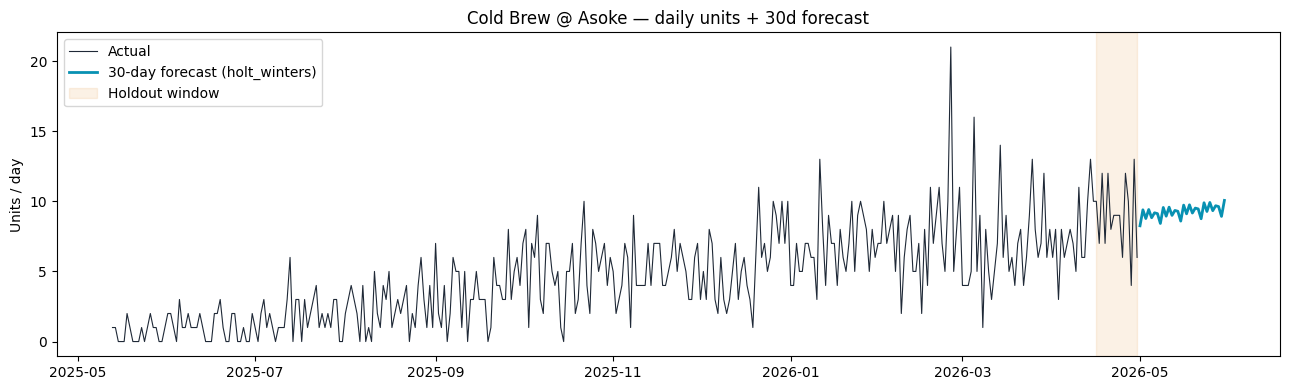

In [8]:
example_sku = target_skus[0]
example_branch = 1  # Asoke
s = make_series(daily, example_sku, example_branch)
fc = forecast_df[(forecast_df.sku_id == example_sku) & (forecast_df.branch_id == example_branch)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index, s.values, label="Actual", color="#1F2937", lw=0.8)
ax.plot(fc['date'], fc['forecast'], label=f"30-day forecast ({fc['method'].iloc[0]})", color="#0891B2", lw=2)
ax.axvspan(s.index.max() - pd.Timedelta(days=14), s.index.max(), alpha=0.1, color="#D97706", label="Holdout window")
prod = products[products.product_id == example_sku]['product'].iloc[0]
br_name = branches[branches.branch_id == example_branch]['branch'].iloc[0]
ax.set_title(f"{prod} @ {br_name} — daily units + 30d forecast", fontsize=12)
ax.set_ylabel("Units / day")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Discussion prompts

1. Why does **seasonal naive** often beat fancier methods? When does **Holt-Winters** earn its keep?
2. Look at the heatmap — are some branches systematically harder to forecast? Why might that be?
3. RMSE penalizes large errors heavily. Would **MAPE** or **MAE** change which method wins?
4. **Operational use:** how would you use these forecasts? Inventory? Staffing? Roasting schedule?

**Next:** Module 3 — predicting who responds to the comeback campaign, with imbalanced classes.